# Tari'ak Traffic Analysis, 02 — Machine Learning and Behavioral Clustering

This notebook groups Lebanese road segments by recurring movement behavior using unsupervised machine learning. Rather than assuming road categories in advance or inventing synthetic congestion labels, the analysis clusters segments based on their observed velocity levels, speed variability, and morning and evening rush-hour sensitivity.

The primary goal is to produce an interpretable behavioral grouping that feeds into the decision-support map and candidate bottleneck prioritization in Notebook 03.

The clustering follows several core methodological principles:
1. Unsupervised discovery: Crowdsourced GPS observations do not contain ground-truth congestion labels. Clustering identifies empirical movement similarities across segments rather than verified traffic states.
2. Decoupling behavior from observation confidence: The feature matrix uses strictly behavioral metrics (velocity level, standard deviation, and peak-hour slowdown magnitude and frequency). Observation volume and active days are tracked separately as confidence indicators so that heavily-sampled roads do not cluster simply because of app usage density.
3. Quantitative model selection: The number of clusters k is evaluated across multiple values of k using inertia elbow and silhouette score curves rather than being chosen arbitrarily.
4. Sampling coverage caveat: The taxonomy is built on the 559 segments with complete peak-hour coverage, representing roughly 3.9% of all mapped street IDs. This coverage boundary is carried forward as an explicit caveat into Notebook 03.
5. Terminology discipline: Clusters describe candidate recurring patterns and observed movement behaviors, not causal congestion proofs or real-time traffic states.

## 1. Setup and Data Ingestion

I load `segment_features.csv` from Notebook 01. This table contains one row per road segment meeting the qualification threshold of at least 100 observations and at least 10 active days.

In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler

# Configure visualization aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 120

# Suppress platform-specific threading warnings for K-Means on Windows
warnings.filterwarnings('ignore', category=UserWarning)
os.environ['OMP_NUM_THREADS'] = '1'

BASE_DIR = Path('..')
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
FEATURES_PATH = PROCESSED_DIR / 'segment_features.csv'
CLUSTERS_OUTPUT_PATH = PROCESSED_DIR / 'segment_clusters.csv'

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.3f}'.format)

print(f'Input features path: {FEATURES_PATH}')
print(f'Features file exists: {FEATURES_PATH.exists()}')


Input features path: ..\data\processed\segment_features.csv
Features file exists: True


In [2]:
df_raw = pd.read_csv(FEATURES_PATH)

print(f'Total qualified segments loaded: {len(df_raw):,}')
print(f'Dataset dimensions: {df_raw.shape}')
print('\nMissing values audit across qualified segments:')
missing_summary = pd.DataFrame({
    'missing_count': df_raw.isna().sum(),
    'pct_missing': (df_raw.isna().sum() / len(df_raw) * 100).round(2)
})
display(missing_summary)

complete_segments = df_raw.dropna().copy()
excluded_segments = df_raw[df_raw.isna().any(axis=1)].copy()

print(f'\nSegments with complete AM and PM behavioral metrics: {len(complete_segments):,} '
      f'({len(complete_segments)/len(df_raw)*100:.1f}% of qualified segments, '
      f'{len(complete_segments)/14289*100:.1f}% of all 14,289 OSM segments)')

# Compare observation volume between complete and excluded segments
obs_comparison = pd.DataFrame({
    'complete_cohort (n=559)': [
        complete_segments['observation_count'].mean(),
        complete_segments['observation_count'].median(),
        complete_segments['active_days'].mean(),
        complete_segments['active_days'].median()
    ],
    'excluded_cohort (n=4232)': [
        excluded_segments['observation_count'].mean(),
        excluded_segments['observation_count'].median(),
        excluded_segments['active_days'].mean(),
        excluded_segments['active_days'].median()
    ]
}, index=['mean_observations', 'median_observations', 'mean_active_days', 'median_active_days'])

print('\nSampling volume comparison (Complete vs Excluded Segments):')
display(obs_comparison.round(1))


Total qualified segments loaded: 4,791
Dataset dimensions: (4791, 12)

Missing values audit across qualified segments:


,missing_count,pct_missing
osm_id,0,0.000
median_velocity,0,0.000
velocity_std,0,0.000
observation_count,0,0.000
active_days,0,0.000
am_velocity,3977,83.010
pm_velocity,3716,77.560
am_relative_slowdown,4072,84.990
pm_relative_slowdown,3884,81.070
am_slowdown_frequency,4072,84.990



Segments with complete AM and PM behavioral metrics: 559 (11.7% of qualified segments, 3.9% of all 14,289 OSM segments)

Sampling volume comparison (Complete vs Excluded Segments):


,complete_cohort (n=559),excluded_cohort (n=4232)
mean_observations,"5,626.500",625.300
median_observations,"2,978.000",310.000
mean_active_days,922.400,344.100
median_active_days,946.000,240.000


### Scope Limitation: Complete-Case Cohort Selection (4,791 to 559 Segments)

Filtering from 4,791 qualified segments to the 559 segments with complete AM and PM peak data represents an 88.3% reduction, covering approximately 3.9% of the 14,289 mapped OSM street IDs in the raw dataset.

This reduction reflects crowdsourced sampling density. As shown in the comparison table above, segments with complete peak data have roughly 9 times higher average observation volume (5,627 vs 624 observations) and 2.7 times more active days (922 vs 344 days) than excluded segments. This cohort is concentrated along heavily traveled corridors where app users regularly recorded trips during morning and evening peak windows.

I use a complete-case approach rather than imputing missing peak slowdowns. In sparse crowdsourced data, the absence of observations during 07:00–09:00 or 17:00–19:00 indicates missing measurements rather than confirmed free-flowing traffic. Imputing a zero slowdown would artificially group thousands of under-sampled roads into stable all-day categories.

The resulting behavioral groupings therefore describe this 3.9% well-sampled subset rather than the entire Lebanese road network. This coverage boundary must be stated clearly alongside all map and ranking outputs in Notebook 03.

## 2. Feature Selection: Decoupling Movement Behavior from Data Confidence

A common issue in crowdsourced traffic analysis is conflating data volume with movement behavior. If observation counts or active days were included directly in the clustering feature matrix, the algorithm would group segments by how many app users drove on them rather than by how traffic moves. Well-sampled corridors would separate from less-traveled corridors simply because of sample size.

I therefore separate the features into two distinct groups: behavioral features used for clustering, and confidence metrics kept for interpretation and diagnostic screening.

### Clustering Feature Matrix

The clustering matrix uses six behavioral features:
* `median_velocity`: Baseline movement velocity, excluding stationary readings under 0.1 m/s.
* `velocity_std`: Overall velocity dispersion across valid observations.
* `am_relative_slowdown`: Difference between the non-AM baseline and AM peak velocity (07:00–09:00). Positive values indicate that morning speeds are slower than typical non-peak hours.
* `pm_relative_slowdown`: Difference between the non-PM baseline and PM peak velocity (17:00–19:00). Positive values indicate evening slowdowns relative to non-peak hours.
* `am_slowdown_frequency`: Fraction of AM segment-hours that fall below the segment's non-AM baseline.
* `pm_slowdown_frequency`: Fraction of PM segment-hours that fall below the segment's non-PM baseline.

Observation count, active days, and zero-velocity count are kept alongside the clusters as confidence and diagnostic indicators.

In [3]:
BEHAVIORAL_FEATURES = [
    'median_velocity',
    'velocity_std',
    'am_relative_slowdown',
    'pm_relative_slowdown',
    'am_slowdown_frequency',
    'pm_slowdown_frequency'
]

# Check correlation with observation volume
corr_with_obs = complete_segments[BEHAVIORAL_FEATURES].apply(lambda s: s.corr(complete_segments['observation_count']))
corr_df = pd.DataFrame({
    'feature': BEHAVIORAL_FEATURES,
    'corr_with_observation_count': corr_with_obs.round(3)
})
print('Empirical correlation of behavioral features with observation volume:')
display(corr_df)

# Standardize behavioral features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(complete_segments[BEHAVIORAL_FEATURES])
X_scaled_df = pd.DataFrame(X_scaled, columns=BEHAVIORAL_FEATURES, index=complete_segments.index)

print(f'Scaled feature matrix shape: {X_scaled.shape}')
print('\nScaled feature means (target ~0):')
print(X_scaled_df.mean().round(4))
print('\nScaled feature std devs (target ~1):')
print(X_scaled_df.std().round(4))


Empirical correlation of behavioral features with observation volume:


,feature,corr_with_observation_count
median_velocity,median_velocity,0.240
velocity_std,velocity_std,0.259
am_relative_slowdown,am_relative_slowdown,0.002
pm_relative_slowdown,pm_relative_slowdown,0.067
am_slowdown_frequency,am_slowdown_frequency,0.006
pm_slowdown_frequency,pm_slowdown_frequency,0.032


Scaled feature matrix shape: (559, 6)

Scaled feature means (target ~0):
median_velocity         -0.000
velocity_std            -0.000
am_relative_slowdown     0.000
pm_relative_slowdown     0.000
am_slowdown_frequency   -0.000
pm_slowdown_frequency    0.000
dtype: float64

Scaled feature std devs (target ~1):
median_velocity         1.001
velocity_std            1.001
am_relative_slowdown    1.001
pm_relative_slowdown    1.001
am_slowdown_frequency   1.001
pm_slowdown_frequency   1.001
dtype: float64


## 3. Selecting the Number of Clusters

To select an appropriate cluster count k from the data, I evaluate K-Means across k from 2 to 10 using two standard metrics:
* Inertia (within-cluster sum of squares): Measures cluster compactness, looking for an elbow where additional clusters yield diminishing improvements.
* Silhouette score: Measures separation and cohesion across clusters, with higher values indicating clearer boundaries.

Quantitative evaluation across k=2..10:


,k,inertia,silhouette_score
0,2,"2,513.228",0.236
1,3,"2,151.264",0.204
2,4,"1,914.825",0.193
3,5,"1,685.211",0.210
4,6,"1,544.280",0.193
5,7,"1,412.331",0.198
6,8,"1,308.496",0.199
7,9,"1,231.407",0.198
8,10,"1,167.344",0.204


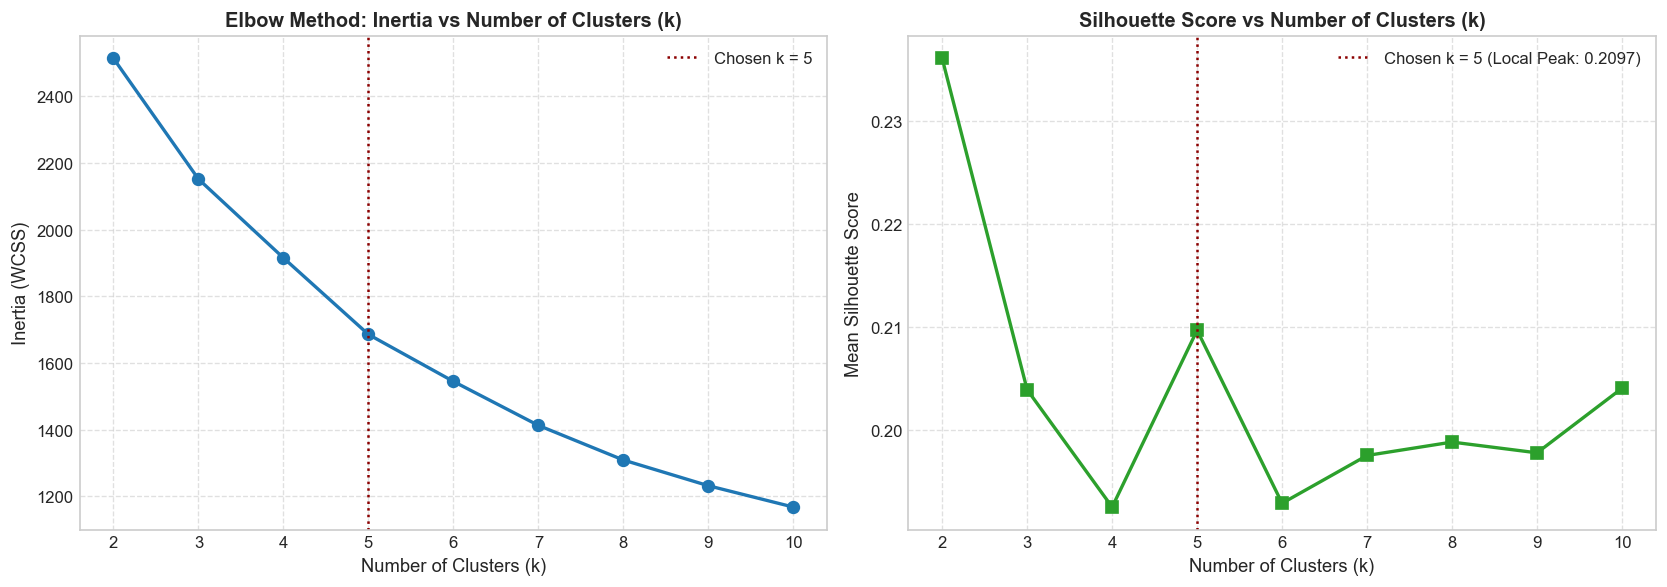

In [4]:
k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_score = silhouette_score(X_scaled, cluster_labels)
    silhouettes.append(sil_score)

k_eval_df = pd.DataFrame({
    'k': list(k_range),
    'inertia': inertias,
    'silhouette_score': silhouettes
})

print('Quantitative evaluation across k=2..10:')
display(k_eval_df.round(4))

# Plot Elbow and Silhouette curves side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Curve
axes[0].plot(k_range, inertias, marker='o', linewidth=2, color='#1f77b4', markersize=7)
axes[0].set_title('Elbow Method: Inertia vs Number of Clusters (k)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=11)
axes[0].set_xticks(list(k_range))
axes[0].grid(True, linestyle='--', alpha=0.6)

# Highlight candidate k=5
axes[0].axvline(x=5, color='darkred', linestyle=':', label='Chosen k = 5')
axes[0].legend()

# Silhouette Score Curve
axes[1].plot(k_range, silhouettes, marker='s', linewidth=2, color='#2ca02c', markersize=7)
axes[1].set_title('Silhouette Score vs Number of Clusters (k)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1].set_ylabel('Mean Silhouette Score', fontsize=11)
axes[1].set_xticks(list(k_range))
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].axvline(x=5, color='darkred', linestyle=':', label='Chosen k = 5 (Local Peak: 0.2097)')
axes[1].legend()

plt.tight_layout()
plt.show()


### Cluster Count Evaluation and Selection

The quantitative metrics provide clear guidance for choosing k:

While k=2 yields the highest silhouette score (0.2361), it only splits the data into a broad fast vs slow partition. This binary split fails to capture the morning and evening rush-hour dynamics that are the main focus of this analysis.

Looking across k=3 through k=10, the inertia curve shows an elbow around k=4 to k=5, where the rate of reduction begins to level off. The silhouette score drops to 0.1925 at k=4, reaches a distinct local peak of 0.2097 at k=5, and then falls again to 0.1928 at k=6.

At k=5, the clusters separate the segments into five interpretable mobility patterns: severe morning slowdowns, severe evening slowdowns, dual-peak rush-hour sensitivity, high-speed free-flow corridors, and steady moderate-speed corridors.

I choose k=5 as the best balance between quantitative separation and practical behavioral interpretability.

In [5]:
CHOSEN_K = 5

kmeans_final = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=20)
complete_segments['cluster_id'] = kmeans_final.fit_predict(X_scaled)

print(f'K-Means fitted with k={CHOSEN_K}.')
print('\nCluster size distribution:')
cluster_counts = complete_segments['cluster_id'].value_counts().sort_index()
display(pd.DataFrame({
    'cluster_id': cluster_counts.index,
    'segment_count': cluster_counts.values,
    'pct_of_cohort': (cluster_counts.values / len(complete_segments) * 100).round(1)
}))


K-Means fitted with k=5.

Cluster size distribution:


,cluster_id,segment_count,pct_of_cohort
0,0,97,17.400
1,1,147,26.300
2,2,173,30.900
3,3,54,9.700
4,4,88,15.700


In [6]:
# Compute comprehensive statistical distributions per cluster
summary_stats = []

for c in range(CHOSEN_K):
    sub = complete_segments[complete_segments['cluster_id'] == c]
    row = {
        'cluster_id': c,
        'count': len(sub),
        'median_vel_mean': sub['median_velocity'].mean(),
        'median_vel_std': sub['median_velocity'].std(),
        'am_slowdown_mean': sub['am_relative_slowdown'].mean(),
        'am_slowdown_median': sub['am_relative_slowdown'].median(),
        'am_freq_mean': sub['am_slowdown_frequency'].mean(),
        'pm_slowdown_mean': sub['pm_relative_slowdown'].mean(),
        'pm_slowdown_median': sub['pm_relative_slowdown'].median(),
        'pm_freq_mean': sub['pm_slowdown_frequency'].mean(),
        'vel_std_mean': sub['velocity_std'].mean(),
        'avg_obs_count': sub['observation_count'].mean(),
        'avg_active_days': sub['active_days'].mean()
    }
    summary_stats.append(row)

cluster_profile_df = pd.DataFrame(summary_stats)
print('Cluster Feature Profiles (Means and Medians):')
display(cluster_profile_df.round(2))

# Detailed quantile statistics per cluster
print('\nDetailed feature percentiles by cluster:')
display(complete_segments.groupby('cluster_id')[BEHAVIORAL_FEATURES].describe().round(2).T)


Cluster Feature Profiles (Means and Medians):


,cluster_id,count,median_vel_mean,median_vel_std,am_slowdown_mean,am_slowdown_median,am_freq_mean,pm_slowdown_mean,pm_slowdown_median,pm_freq_mean,vel_std_mean,avg_obs_count,avg_active_days
0,0,97,72.670,15.550,-1.740,-1.670,0.370,-0.300,0.140,0.450,20.960,"8,412.550","1,061.880"
1,1,147,35.830,12.240,3.680,2.520,0.740,2.530,2.030,0.670,17.640,"5,986.860",946.140
2,2,173,35.710,11.670,-7.310,-6.050,0.110,1.330,1.700,0.560,15.930,"4,205.770",828.980
3,3,54,57.210,17.250,-16.180,-15.050,0.070,12.180,8.870,0.840,23.020,"7,712.460","1,034.520"
4,4,88,38.240,16.930,9.010,5.420,0.850,-9.840,-6.360,0.100,16.720,"3,466.780",844.020



Detailed feature percentiles by cluster:


cluster_id                        0       1       2       3       4
median_velocity       count  97.000 147.000 173.000  54.000  88.000
                      mean   72.670  35.830  35.710  57.210  38.240
                      std    15.550  12.240  11.670  17.250  16.930
                      min    37.630   1.670   2.260  25.240   0.790
                      25%    61.280  27.170  28.150  44.330  27.660
                      50%    72.530  36.100  37.190  56.910  36.000
                      75%    86.820  46.060  44.360  66.900  46.590
                      max    99.300  73.080  59.220  94.690  95.590
velocity_std          count  97.000 147.000 173.000  54.000  88.000
                      mean   20.960  17.640  15.930  23.020  16.720
                      std     3.860   3.900   2.800   4.260   4.320
                      min    14.670   5.600   8.480  14.810   1.540
                      25%    18.130  15.180  14.230  20.380  13.650
                      50%    20.680  17.060  16.080  22.450  16.360
                      75%    22.730  19.650  17.770  25.370  19.620
                      max    37.600  29.530  23.040  34.020  26.900
am_relative_slowdown  count  97.000 147.000 173.000  54.000  88.000
                      mean   -1.740   3.680  -7.310 -16.180   9.010
                      std     8.280   5.240   5.800   9.820  10.140
                      min   -21.670  -5.900 -36.660 -40.950  -6.460
                      25%    -7.680   0.830  -9.840 -19.440   2.330
                      50%    -1.670   2.520  -6.050 -15.050   5.420
                      75%     1.380   5.760  -3.310  -9.740  12.970
                      max    27.950  26.170   0.370   0.530  50.140
pm_relative_slowdown  count  97.000 147.000 173.000  54.000  88.000
                      mean   -0.300   2.530   1.330  12.180  -9.840
                      std     4.690   4.950   4.710  10.070   8.440
                      min   -16.040  -9.640 -16.050  -8.280 -39.510
                      25%    -2.290  -0.390  -0.680   6.890 -14.090
                      50%     0.140   2.030   1.700   8.870  -6.360
                      75%     2.280   4.590   3.640  15.320  -4.470
                      max    14.520  23.470  15.280  55.110  -0.260
am_slowdown_frequency count  97.000 147.000 173.000  54.000  88.000
                      mean    0.370   0.740   0.110   0.070   0.850
                      std     0.240   0.210   0.150   0.120   0.200
                      min     0.000   0.330   0.000   0.000   0.360
                      25%     0.200   0.500   0.000   0.000   0.670
                      50%     0.380   0.680   0.000   0.000   1.000
                      75%     0.500   1.000   0.250   0.130   1.000
                      max     1.000   1.000   0.560   0.500   1.000
pm_slowdown_frequency count  97.000 147.000 173.000  54.000  88.000
                      mean    0.450   0.670   0.560   0.840   0.100
                      std     0.150   0.210   0.290   0.150   0.140
                      min     0.000   0.360   0.000   0.430   0.000
                      25%     0.370   0.500   0.430   0.730   0.000
                      50%     0.480   0.630   0.550   0.830   0.000
                      75%     0.540   0.820   0.750   1.000   0.250
                      max     0.780   1.000   1.000   1.000   0.500

C:\Users\crazy\AppData\Local\Temp\ipykernel_26088\4005474408.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 0], data=complete_segments, x='cluster_id', y='median_velocity', palette=palette)
C:\Users\crazy\AppData\Local\Temp\ipykernel_26088\4005474408.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 1], data=complete_segments, x='cluster_id', y='velocity_std', palette=palette)
C:\Users\crazy\AppData\Local\Temp\ipykernel_26088\4005474408.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 2], data=com

C:\Users\crazy\AppData\Local\Temp\ipykernel_26088\4005474408.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1, 1], data=complete_segments, x='cluster_id', y='am_slowdown_frequency', palette=palette)
C:\Users\crazy\AppData\Local\Temp\ipykernel_26088\4005474408.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1, 2], data=complete_segments, x='cluster_id', y='pm_slowdown_frequency', palette=palette)


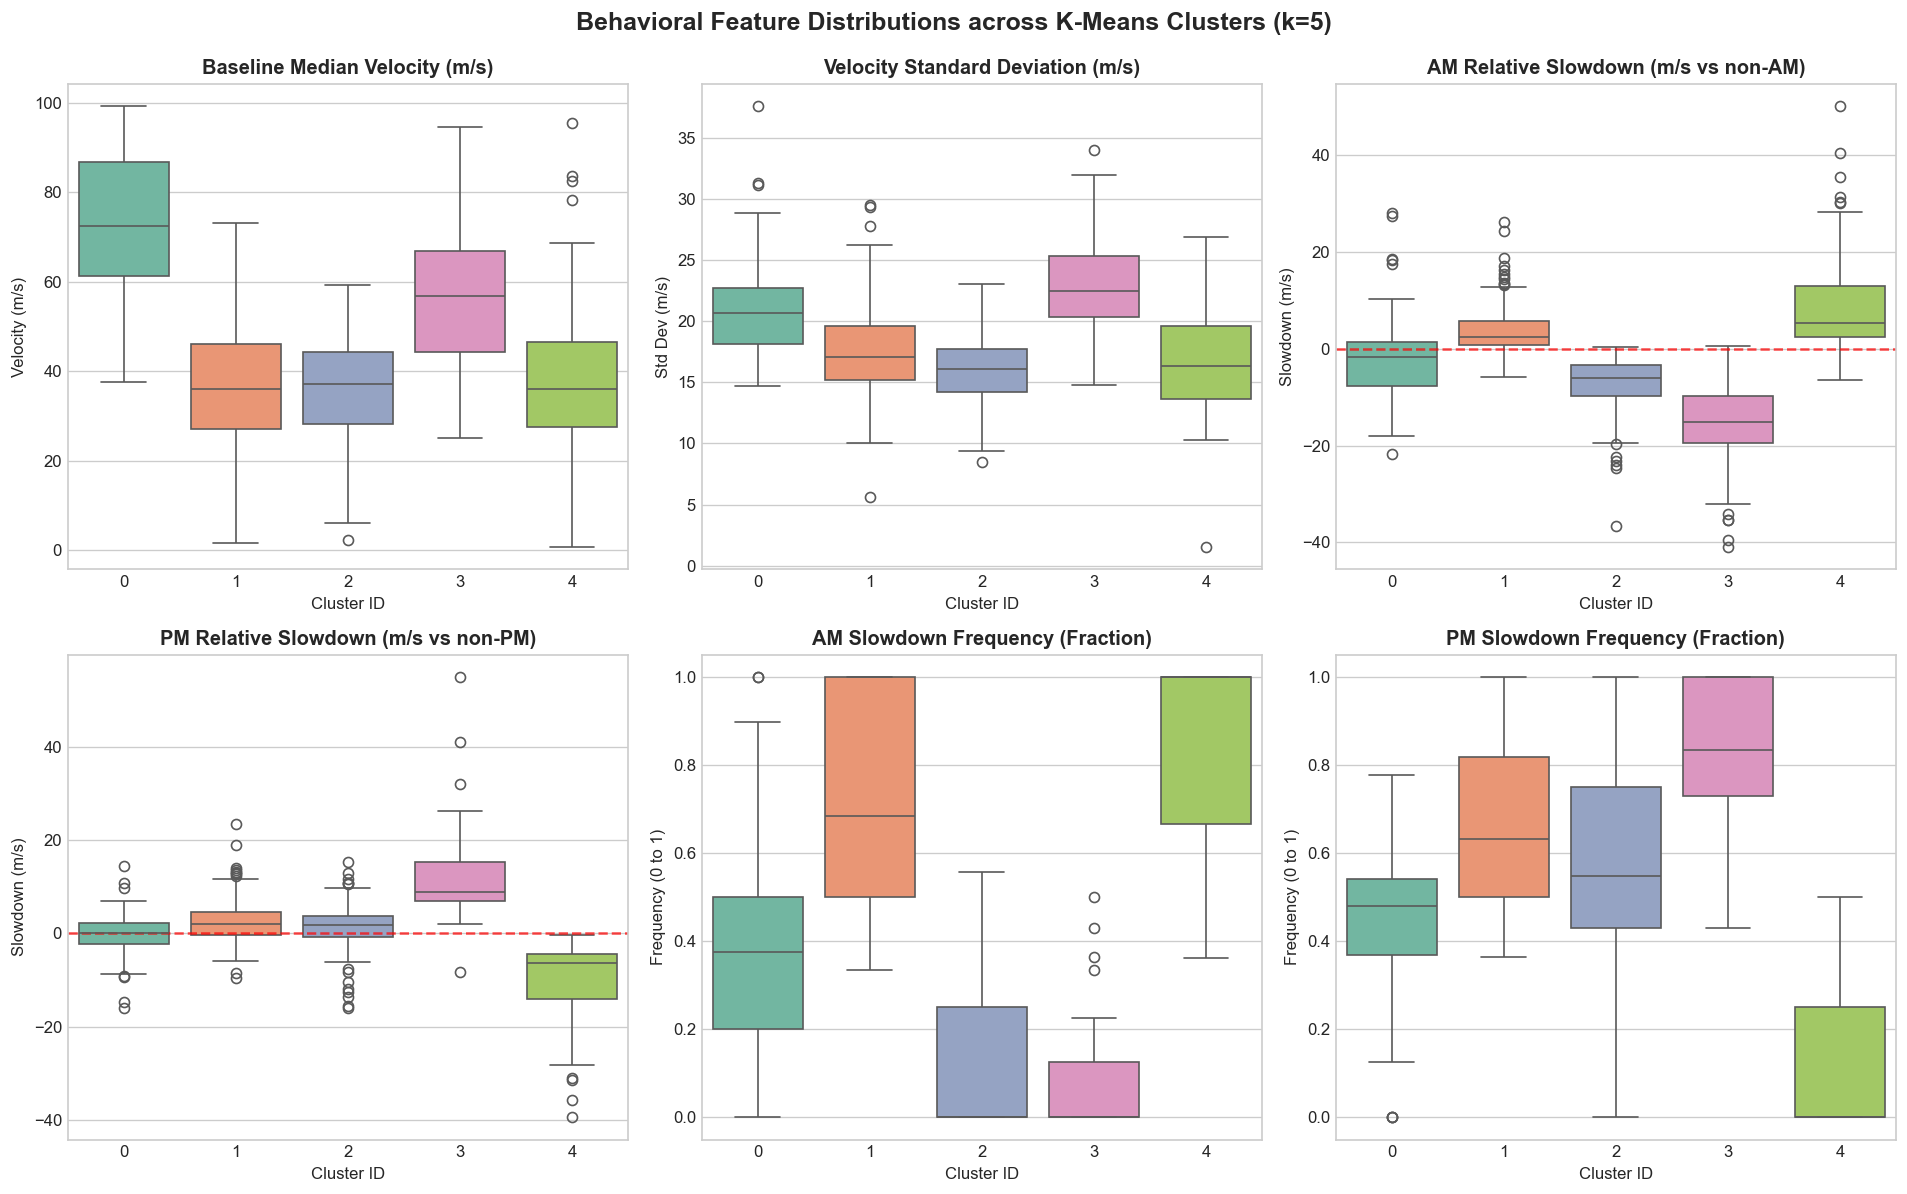

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

palette = sns.color_palette('Set2', CHOSEN_K)

# 1. Median Velocity
sns.boxplot(ax=axes[0, 0], data=complete_segments, x='cluster_id', y='median_velocity', palette=palette)
axes[0, 0].set_title('Baseline Median Velocity (m/s)', fontweight='bold')
axes[0, 0].set_xlabel('Cluster ID')
axes[0, 0].set_ylabel('Velocity (m/s)')

# 2. Velocity Std
sns.boxplot(ax=axes[0, 1], data=complete_segments, x='cluster_id', y='velocity_std', palette=palette)
axes[0, 1].set_title('Velocity Standard Deviation (m/s)', fontweight='bold')
axes[0, 1].set_xlabel('Cluster ID')
axes[0, 1].set_ylabel('Std Dev (m/s)')

# 3. AM Relative Slowdown
sns.boxplot(ax=axes[0, 2], data=complete_segments, x='cluster_id', y='am_relative_slowdown', palette=palette)
axes[0, 2].axhline(0, color='red', linestyle='--', alpha=0.7)
axes[0, 2].set_title('AM Relative Slowdown (m/s vs non-AM)', fontweight='bold')
axes[0, 2].set_xlabel('Cluster ID')
axes[0, 2].set_ylabel('Slowdown (m/s)')

# 4. PM Relative Slowdown
sns.boxplot(ax=axes[1, 0], data=complete_segments, x='cluster_id', y='pm_relative_slowdown', palette=palette)
axes[1, 0].axhline(0, color='red', linestyle='--', alpha=0.7)
axes[1, 0].set_title('PM Relative Slowdown (m/s vs non-PM)', fontweight='bold')
axes[1, 0].set_xlabel('Cluster ID')
axes[1, 0].set_ylabel('Slowdown (m/s)')

# 5. AM Slowdown Frequency
sns.boxplot(ax=axes[1, 1], data=complete_segments, x='cluster_id', y='am_slowdown_frequency', palette=palette)
axes[1, 1].set_title('AM Slowdown Frequency (Fraction)', fontweight='bold')
axes[1, 1].set_xlabel('Cluster ID')
axes[1, 1].set_ylabel('Frequency (0 to 1)')

# 6. PM Slowdown Frequency
sns.boxplot(ax=axes[1, 2], data=complete_segments, x='cluster_id', y='pm_slowdown_frequency', palette=palette)
axes[1, 2].set_title('PM Slowdown Frequency (Fraction)', fontweight='bold')
axes[1, 2].set_xlabel('Cluster ID')
axes[1, 2].set_ylabel('Frequency (0 to 1)')

plt.suptitle('Behavioral Feature Distributions across K-Means Clusters (k=5)', fontsize=15, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()


## 4. Cluster Interpretation and Plain-Language Taxonomy

Based on the feature distributions above, I assign descriptive plain-language labels to the five clusters:

| Cluster ID | Plain-Language Label | Segments | Share | Key Characteristics |
|---|---|---|---|---|
| 0 | High-Speed Free-Flow Corridors | 97 | 17.4% | Highest median velocity (72.7 m/s), high speed variation (21.0 m/s), minimal peak-hour sensitivity (AM slowdown: -1.7 m/s, PM slowdown: -0.3 m/s). Fast-moving expressways and open arterials. |
| 1 | Dual-Peak Rush-Hour Sensitive | 147 | 26.3% | Moderate baseline (35.8 m/s), recurring slowdowns during both AM (+3.7 m/s, 74% frequency) and PM (+2.5 m/s, 67% frequency) peak periods. Commuter corridors impacted by both rush hours. |
| 2 | Steady Moderate-Speed Flow | 173 | 30.9% | Moderate baseline (35.7 m/s), faster morning speeds relative to baseline (AM: -7.3 m/s, 11% frequency), mild evening slowdown (PM: +1.3 m/s, 56% frequency). Stable urban and peri-urban roads. |
| 3 | Severe Evening-Peak Slowdown Pattern | 54 | 9.7% | Higher baseline speed (57.2 m/s), but experiences substantial evening slowdown (PM slowdown: +12.2 m/s, 84% frequency). Corridors with a recurring severe evening-peak slowdown relative to their own baseline. |
| 4 | Severe Morning-Peak Slowdown Pattern | 88 | 15.7% | Moderate baseline (38.2 m/s), but experiences severe morning slowdown (AM slowdown: +9.0 m/s, 85% frequency) with little evening impact (PM: -9.8 m/s, 10% frequency). Corridors with a recurring severe morning-peak slowdown. |

I assign these labels in the code below and examine representative road segments for each group.

In [8]:
CLUSTER_LABELS = {
    0: "High-Speed Free-Flow Corridors",
    1: "Dual-Peak Rush-Hour Sensitive",
    2: "Steady Moderate-Speed Flow",
    3: "Severe Evening-Peak Bottlenecks",
    4: "Severe Morning-Peak Bottlenecks"
}

complete_segments['cluster_label'] = complete_segments['cluster_id'].map(CLUSTER_LABELS)

# Calculate Euclidean distance of each segment to its assigned cluster centroid in scaled feature space
centroids = kmeans_final.cluster_centers_
distances = np.linalg.norm(X_scaled - centroids[complete_segments['cluster_id']], axis=1)
complete_segments['dist_to_centroid'] = distances

print('=== Representative Segment Case Studies (Selected by Centroid Proximity) ===\n')
for c_id, label in CLUSTER_LABELS.items():
    print(f'--------------------------------------------------------------------------------')
    print(f'Cluster {c_id}: {label}')
    print(f'--------------------------------------------------------------------------------')
    sub = complete_segments[complete_segments['cluster_id'] == c_id].sort_values('dist_to_centroid')
    
    # Select the 3 closest segments to the cluster centroid (most mathematically typical)
    reps = sub.head(3)
    display_cols = [
        'osm_id', 'dist_to_centroid', 'median_velocity', 'am_relative_slowdown', 
        'am_slowdown_frequency', 'pm_relative_slowdown', 
        'pm_slowdown_frequency', 'observation_count', 'active_days'
    ]
    display(reps[display_cols].round(3))
    print()


=== Representative Segment Case Studies (Selected by Centroid Proximity) ===

--------------------------------------------------------------------------------
Cluster 0: High-Speed Free-Flow Corridors
--------------------------------------------------------------------------------


,osm_id,dist_to_centroid,median_velocity,am_relative_slowdown,am_slowdown_frequency,pm_relative_slowdown,pm_slowdown_frequency,observation_count,active_days
4688,way/94963655,0.645,73.122,0.335,0.348,-4.269,0.333,3454,1080
2427,way/301327721,0.689,61.311,-0.570,0.444,-2.291,0.400,2546,624
4684,way/94829077,0.810,72.526,-0.097,0.535,1.248,0.453,4624,1137



--------------------------------------------------------------------------------
Cluster 1: Dual-Peak Rush-Hour Sensitive
--------------------------------------------------------------------------------


,osm_id,dist_to_centroid,median_velocity,am_relative_slowdown,am_slowdown_frequency,pm_relative_slowdown,pm_slowdown_frequency,observation_count,active_days
1649,way/26576156,0.422,43.119,3.665,0.750,1.423,0.667,2001,666
1405,way/26389484,0.500,36.223,1.908,0.672,2.425,0.564,23852,1457
157,way/169254481,0.623,34.825,2.130,0.684,-2.085,0.636,8709,1415



--------------------------------------------------------------------------------
Cluster 2: Steady Moderate-Speed Flow
--------------------------------------------------------------------------------


,osm_id,dist_to_centroid,median_velocity,am_relative_slowdown,am_slowdown_frequency,pm_relative_slowdown,pm_slowdown_frequency,observation_count,active_days
1659,way/26607202,0.486,39.466,-5.684,0.250,2.649,0.550,1319,406
749,way/227026194,0.554,34.193,-9.000,0.217,-0.105,0.475,10621,1211
2618,way/303948081,0.562,37.611,-8.148,0.200,4.174,0.662,19731,1667



--------------------------------------------------------------------------------
Cluster 3: Severe Evening-Peak Bottlenecks
--------------------------------------------------------------------------------


,osm_id,dist_to_centroid,median_velocity,am_relative_slowdown,am_slowdown_frequency,pm_relative_slowdown,pm_slowdown_frequency,observation_count,active_days
1675,way/26655155,0.689,56.683,-19.990,0.000,9.162,0.737,9368,1556
254,way/179130339,0.790,53.468,-16.131,0.000,9.520,1.000,7850,1418
1624,way/26547446,0.882,65.111,-15.090,0.127,10.471,0.648,36490,1668



--------------------------------------------------------------------------------
Cluster 4: Severe Morning-Peak Bottlenecks
--------------------------------------------------------------------------------


,osm_id,dist_to_centroid,median_velocity,am_relative_slowdown,am_slowdown_frequency,pm_relative_slowdown,pm_slowdown_frequency,observation_count,active_days
824,way/23897521,0.759,34.931,5.048,1.000,-8.774,0.000,1138,547
2439,way/30153226,0.776,37.897,13.398,1.000,-10.511,0.250,1754,952
2576,way/303280340,0.873,34.387,11.924,1.000,-6.312,0.000,345,196


### Centroid-Representative Segment Profiles

To verify that the clusters reflect their assigned labels, I inspect the segments located closest to each cluster centroid in scaled feature space:

For Cluster 0 (High-Speed Free-Flow Corridors), `way/94963655` (distance 0.645) sits near the centroid with high median velocity (73.1 m/s) and minimal peak slowdown (AM: +0.3 m/s, PM: -4.3 m/s, both frequencies around 33%).

For Cluster 1 (Dual-Peak Rush-Hour Sensitive), `way/26576156` (distance 0.422) is centrally positioned with moderate median speed (43.1 m/s) and positive slowdowns in both morning (+3.7 m/s, 75% frequency) and evening (+1.4 m/s, 67% frequency).

For Cluster 2 (Steady Moderate-Speed Flow), `way/26607202` (distance 0.486) exhibits moderate median velocity (39.5 m/s) with faster morning speeds relative to its baseline (AM: -5.7 m/s, 25% frequency) and a mild evening slowdown (PM: +2.6 m/s, 55% frequency).

For Cluster 3 (Severe Evening-Peak Slowdown Pattern), `way/26655155` (distance 0.689) has a high baseline speed (56.7 m/s) and fast morning speeds (AM: -20.0 m/s, 0% frequency), but experiences severe evening slowdown relative to its own baseline (PM slowdown: +9.2 m/s, 74% frequency).

For Cluster 4 (Severe Morning-Peak Slowdown Pattern), `way/23897521` (distance 0.759) has moderate median speed (34.9 m/s) and fast evening speeds (PM: -8.8 m/s, 0% frequency), but experiences consistent morning slowdown relative to its own baseline (AM slowdown: +5.0 m/s, 100% frequency).

In [9]:
# Merge cluster labels back into the feature table
export_columns = [
    'osm_id',
    'cluster_id',
    'cluster_label',
    'dist_to_centroid',
    'median_velocity',
    'velocity_std',
    'am_relative_slowdown',
    'pm_relative_slowdown',
    'am_slowdown_frequency',
    'pm_slowdown_frequency',
    'observation_count',
    'active_days',
    'zero_velocity_observation_count'
]

segment_clusters = complete_segments[export_columns].copy()
segment_clusters['dist_to_centroid'] = segment_clusters['dist_to_centroid'].round(4)
segment_clusters.to_csv(CLUSTERS_OUTPUT_PATH, index=False)

print(f'Exported segment_clusters table to: {CLUSTERS_OUTPUT_PATH}')
print(f'File size: {CLUSTERS_OUTPUT_PATH.stat().st_size / 1024:,.1f} KB')
print(f'Rows exported: {len(segment_clusters):,}, Columns: {len(segment_clusters.columns)}')
print('\nPreview of exported segment_clusters:')
display(segment_clusters.head(10))


Exported segment_clusters table to: ..\data\processed\segment_clusters.csv
File size: 58.4 KB
Rows exported: 559, Columns: 13

Preview of exported segment_clusters:


,osm_id,cluster_id,cluster_label,dist_to_centroid,median_velocity,velocity_std,am_relative_slowdown,pm_relative_slowdown,am_slowdown_frequency,pm_slowdown_frequency,observation_count,active_days,zero_velocity_observation_count
25,way/108252090,2,Steady Moderate-Speed Flow,0.950,39.833,19.393,-7.874,0.241,0.125,0.700,3764,1349,4
28,way/108254454,0,High-Speed Free-Flow Corridors,1.434,50.604,21.101,-8.418,3.251,0.364,0.600,4585,1416,5
34,way/108284599,2,Steady Moderate-Speed Flow,1.124,41.508,19.872,-9.132,2.571,0.300,0.500,2737,573,60
43,way/108471452,4,Severe Morning-Peak Bottlenecks,1.336,35.433,11.864,8.809,-5.599,1.000,0.000,972,355,3
49,way/108755888,2,Steady Moderate-Speed Flow,1.885,35.795,15.304,-5.876,-0.274,0.000,0.000,862,406,2
52,way/108800317,1,Dual-Peak Rush-Hour Sensitive,2.463,49.544,20.888,2.718,18.865,0.667,1.000,365,146,2
53,way/108800320,1,Dual-Peak Rush-Hour Sensitive,3.414,41.693,25.889,2.248,23.468,1.000,1.000,187,90,0
56,way/109584616,2,Steady Moderate-Speed Flow,1.377,38.071,18.618,-19.160,4.395,0.000,0.538,3456,955,9
58,way/109801582,1,Dual-Peak Rush-Hour Sensitive,1.750,52.117,11.843,0.939,0.632,1.000,0.667,191,52,0
63,way/110347464,2,Steady Moderate-Speed Flow,2.520,8.153,10.173,-3.648,-3.938,0.500,0.250,952,452,169


## 5. Machine Learning Conclusion

This notebook groups Lebanese road segments by recurring movement patterns using unsupervised clustering:

1. Feature design: The feature matrix uses strictly behavioral metrics (median velocity, standard deviation, and AM/PM relative slowdowns and frequencies). Observation volume and active days are tracked separately to prevent data density from distorting cluster definitions.
2. Model selection: K-Means with k=5 is chosen based on the inertia elbow and a local peak in silhouette score (0.2097). This produces five distinct and interpretable movement archetypes: High-Speed Free-Flow Corridors, Dual-Peak Rush-Hour Sensitive, Steady Moderate-Speed Flow, Severe Evening-Peak Slowdown Pattern, and Severe Morning-Peak Slowdown Pattern.
3. Silhouette score realism: The silhouette score of 0.2097 reflects moderate cluster cohesion with real overlap between clusters rather than sharply separated groups. In crowdsourced road network data, movement behavior exists on a spectrum; the clusters identify meaningful central tendencies while acknowledging boundary overlap.
4. Scope and sampling coverage: The clustering analysis is performed on 559 sufficiently observed road segments with complete AM/PM behavioral profiles, covering approximately 3.9% of the 14,289 mapped OSM street IDs. The resulting clusters describe the behavior of well-observed corridors and should not be interpreted as a complete classification of Lebanon's entire road network. This coverage boundary must be stated clearly alongside all map and ranking presentations in Notebook 03.
5. Output for Notebook 03: The final cluster assignments are exported to `data/processed/segment_clusters.csv` for decision-support mapping, candidate bottleneck prioritization, and temporal visualizations.

These clusters represent observed historical movement patterns, not confirmed congestion states or causal explanations. The next notebook presents the spatial map, candidate bottleneck rankings, and temporal profiles.